In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers , models
import matplotlib.pyplot as plt

2026-03-12 20:55:43.893018: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-12 20:55:43.926535: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-12 20:55:44.688040: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
(x_train , y_train) , (x_test , y_test) = tf.keras.datasets.mnist.load_data()

In [3]:
x_train = x_train.astype("float32")/255
x_test = x_test.astype("float32")/255

print(x_test.shape)
print(x_train.shape)


(10000, 28, 28)
(60000, 28, 28)


In [4]:
x_train = x_train.reshape(len(x_train), 28 , 28 , 1)
x_test = x_test.reshape(len(x_test), 28 , 28 , 1)

y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

print(x_test.shape)
print(x_train.shape)

print(y_train[0])

(10000, 28, 28, 1)
(60000, 28, 28, 1)
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [5]:
myInput = layers.Input(shape=(28,28,1))
conv1 = layers.Conv2D(32, (3,3), padding='same', strides=2)(myInput)
bn1 = layers.BatchNormalization()(conv1)
ac1 = layers.Activation('relu')(bn1)
conv2 = layers.Conv2D(64, (3,3), padding='same', strides=2)(ac1)
bn2 = layers.BatchNormalization()(conv2)
ac2 = layers.Activation('relu')(bn2)
# mp = layers.MaxPooling2D((2, 2))(ac2)
flat = layers.Flatten()(ac2)
out_layer = layers.Dense(10, activation='softmax')(flat)

myModel = models.Model(myInput, out_layer)

myModel.summary()

I0000 00:00:1773345345.712409  148505 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4575 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        31,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,570 (197.54 KB)

 Trainable params: 50,378 (196.79 KB)

 Non-trainable params: 192 (768.00 B)

In [6]:
myModel.compile(
    optimizer="AdaMax",
    loss=tf.keras.losses.categorical_crossentropy,
    metrics=['accuracy']
    )

history = myModel.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.1
    )

Epoch 1/10


2026-03-12 20:55:46.886286: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fdce800b320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-12 20:55:46.886303: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2026-03-12 20:55:46.912781: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-12 20:55:46.996811: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91600


 77/422 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6587 - loss: 1.0996

I0000 00:00:1773345348.190466  148567 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9117 - loss: 0.3129 - val_accuracy: 0.9552 - val_loss: 0.3307
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9675 - loss: 0.1185 - val_accuracy: 0.9792 - val_loss: 0.0817
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9781 - loss: 0.0794 - val_accuracy: 0.9823 - val_loss: 0.0634
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9828 - loss: 0.0606 - val_accuracy: 0.9827 - val_loss: 0.0600
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9863 - loss: 0.0494 - val_accuracy: 0.9848 - val_loss: 0.0561
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9889 - loss: 0.0409 - val_accuracy: 0.9852 - val_loss: 0.0514
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9909 - loss: 0.0344 - val_accuracy: 0.9860 - val_loss: 0.0515
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9918 - loss: 0.0299 - val_accuracy: 0.9868 - val_

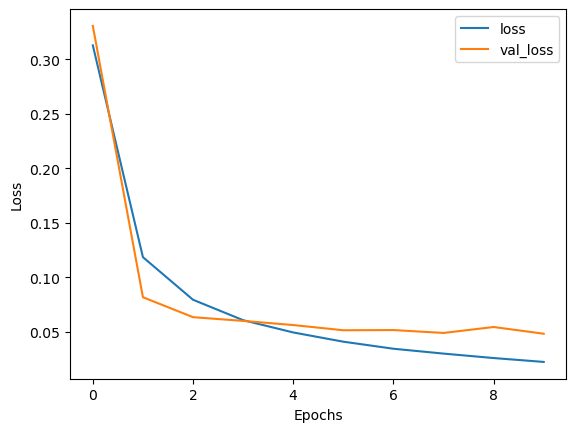

In [7]:
# Plot Losses
losses = history.history['loss']
val_losses = history.history['val_loss']

plt.plot(losses)
plt.plot(val_losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['loss', 'val_loss'])

In [8]:
# Evaluation on Test Data
test_loss = myModel.evaluate(x_test, y_test)
print("test loss: ", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9863 - loss: 0.0413
test loss:  [0.04134877026081085, 0.986299991607666]
